In [1]:
import numpy as np
import os
import mediapipe as mp
import cv2
from matplotlib import pyplot as plt
import time

# 2. Landmarks detection

In [2]:
# ------------------------------------------ Set up mediapipe holistic -----------------------------------------------------
mp_holistic = mp.solutions.holistic          # Holistic model
mp_drawing = mp.solutions.drawing_utils      # Drawing utilities

In [3]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB. Necessary for mediapipe to do a detection
    image.flags.writeable = False                   # Set it to unwritable to save memory
    results = model.process(image)                  # Process the image (perform detection) using mediapipe
    image.flags.writeable = True                    # Set it back to writeable
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)  # Convert from RGB to BGR
    return image, results

In [4]:
# Render results, in order to see the landmarks.

def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp.solutions.holistic.FACEMESH_TESSELATION)       # Draw connectiond between face landmarks
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp.solutions.holistic.POSE_CONNECTIONS)
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)

In [5]:
# Advanced version: choose the style for connections and landmark rendering. From the documentation (mp_drawing.draw_landmarks??):
# mp_drawing.draw_landmarks(
#    image: numpy.ndarray,
#    landmark_list: mediapipe.framework.formats.landmark_pb2.NormalizedLandmarkList,
#    connections: Optional[List[Tuple[int, int]]] = None,
#    landmark_drawing_spec: Union[mediapipe.python.solutions.drawing_utils.DrawingSpec, Mapping[int, mediapipe.python.solutions.drawing_utils.DrawingSpec], NoneType] = DrawingSpec(color=(0, 0, 255), thickness=2, circle_radius=2),
#    connection_drawing_spec: Union[mediapipe.python.solutions.drawing_utils.DrawingSpec, Mapping[Tuple[int, int], mediapipe.python.solutions.drawing_utils.DrawingSpec]] = DrawingSpec(color=(224, 224, 224), thickness=2, circle_radius=2),
#    is_drawing_landmarks: bool = True,
# )
# Note the that the color palette is in BGR, not in RGB because this step is performed in between color corrections

def draw_styled_landmarks(image, results):
    # mp_drawing.draw_landmarks(image, results.face_landmarks, mp.solutions.holistic.FACEMESH_TESSELATION,
    #                           mp_drawing.DrawingSpec(color= (80, 110, 10), thickness = 1, circle_radius = 1),    # Landmarks specifications
    #                           mp_drawing.DrawingSpec(color= (80, 256, 10), thickness = 1, circle_radius = 1))    # Connections specifications                        
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp.solutions.holistic.POSE_CONNECTIONS,
                              mp_drawing.DrawingSpec(color= (165, 255, 254), thickness = 1, circle_radius = 2),    # Landmarks specifications
                              mp_drawing.DrawingSpec(color= (44, 167, 236), thickness = 1, circle_radius = 2))
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS,
                              mp_drawing.DrawingSpec(color= (165, 255, 254), thickness = 1, circle_radius = 2),    # Landmarks specifications
                              mp_drawing.DrawingSpec(color= (44, 167, 236), thickness = 1, circle_radius = 2))    # Connections specifications
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS,
                              mp_drawing.DrawingSpec(color= (165, 255, 254), thickness = 1, circle_radius = 2),    # Landmarks specifications
                              mp_drawing.DrawingSpec(color= (44, 167, 236), thickness = 1, circle_radius = 2))    # Connections specifications

In [6]:
#------------------------------------------- Keypoints using MP holistic ----------------------------------------------------
# Access webcam: Set up a video capture and loop through frames
cap = cv2.VideoCapture(0)                     # Accessing webcam (VideoCapture object number 0)
# Access mediapipe model. Mediapipe makes an intial detection and tracks keypoints from there -> detection is the first step, tracking is everything that follows
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic: 
    while cap.isOpened():                         # Doublecheck that the webcam is opened
        # Read Feed
        ret, frame = cap.read()                   # return value, image from the webcam = cap.read()

        # Perform detection
        image, results = mediapipe_detection(frame, holistic)

        # Visualize the landmarks
        draw_styled_landmarks(image, results)

        # Show feed to the screen
        cv2.imshow('OpenCV Feed', image)          # cv2.imshow('Frame name', frame). Use frame for the webcame, image for the processed image

        # Getting out of the loop
        if cv2.waitKey(10) & 0xFF == ord('q'):    # wait until a key is pressed and if the key is q, get out of the loop
            break

# Once it breaks, release the webcame and close the frame
cap.release()
cv2.destroyAllWindows()

# results is a variable containing some sets of landmarks. These landmarks can be called as results.face_landmarks, results.left_hand_landmarks, etc
# More specifically, the landmarks are the distances from the camera in a X,Y,Z reference system. 
# If the target is not detected, face and hand models will return no results (results = empty array), while the pose model will return "not visible"
# That's why pose will also include one additional attribute results.visibility, unlike face and hands.

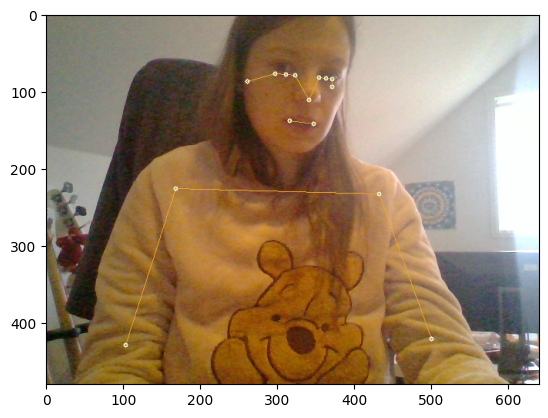

In [7]:
# Optional: visualize the landmarks as coordinates
results.left_hand_landmarks
# Optional: visualize last frame with real colors. If you only use plt.imshow(frame), colors will be off
draw_styled_landmarks(frame, results)
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

# 3. Extract Keypoint Values

In [8]:
results.face_landmarks.landmark


[x: 0.52810603
y: 0.2758864
z: -0.026013564
, x: 0.5388423
y: 0.23509361
z: -0.04616374
, x: 0.53144133
y: 0.24718979
z: -0.02416516
, x: 0.5320004
y: 0.19278727
z: -0.03690083
, x: 0.54099476
y: 0.22261135
z: -0.049128268
, x: 0.54121286
y: 0.2061014
z: -0.045569528
, x: 0.53930086
y: 0.16539629
z: -0.02218483
, x: 0.46332347
y: 0.14550433
z: -0.0056237113
, x: 0.5412933
y: 0.13239124
z: -0.01645074
, x: 0.54381967
y: 0.11501316
z: -0.018225659
, x: 0.54911506
y: 0.05131927
z: -0.008743643
, x: 0.52703947
y: 0.2823043
z: -0.024940975
, x: 0.525377
y: 0.2877271
z: -0.02184785
, x: 0.52368695
y: 0.29042536
z: -0.017867543
, x: 0.52310723
y: 0.29851896
z: -0.016122032
, x: 0.52281904
y: 0.30504504
z: -0.017291322
, x: 0.52198136
y: 0.31290692
z: -0.018472059
, x: 0.52037877
y: 0.32042307
z: -0.016009377
, x: 0.51642865
y: 0.3292024
z: -0.0060777236
, x: 0.53629047
y: 0.24129875
z: -0.04174451
, x: 0.52574295
y: 0.23949885
z: -0.031775374
, x: 0.42226675
y: 0.08352323
z: 0.02658208
, x: 0

In [7]:
# Now we want to make the algorithm more solid, by adding a backup in case the model reports no value; an np.zeros() array will be created, 
# with the same size as the previous one

# The lengths are standard and depend on the model; for example, the face is modeled by 468 landmarks so the lenght of results.face_landmarks is 
# 468 * 3 (X, Y, Z). Pose has 33 landmarks, so the total length of the flattened array will be 33 * 4 (X, Y, Z, visibility). The hands have 21
# landmarks each.

def extract_keypoints(results):
    if results.pose_landmarks:
        pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark])
        pose = (pose - pose[0]).flatten() 
    else: pose = np.zeros(33 * 4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468 * 3)
    # Array containing all the pose landmarks for a specific frame. The same instruction for left hand (note, there is no visibility attribute for
    # hands) will give error if there is no left hand in the frame. That's why we create the zero array.
    if results.left_hand_landmarks:
        left_hand = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark])
        left_hand = (left_hand - left_hand[0]).flatten()
    else:
        left_hand = np.zeros(21 * 3)

    if results.right_hand_landmarks:
        right_hand = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark])
        right_hand = (right_hand - right_hand[0]).flatten()
    else:
        right_hand = np.zeros(21 * 3)

    # return np.concatenate([pose, face, left_hand, right_hand])                                                                                  
    return np.concatenate([pose, left_hand, right_hand])                                                                                  

# 4. Setup folders for collection

In [8]:
DATA_PATH = os.path.join('MP_Data')                    # Path for the exported data
actions = np.array(['Hello', 'Thanks', 'I love you', 'World', 'Background'])  # Actions we try to detect
# We're gonna use 30 sequences (30 videos) of 30 frames each for each action
no_sequences = 30                                     
sequence_length = 30

In [12]:
# Create a different folder for each action, divided in subfolders containing one sequence every time
for action in actions:
    for sequence in range(no_sequences):
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)), exist_ok=True)

# 5. Collect Keypoint values for Training and Testing

In [10]:
# Look through the actions and the frames this time, not through the webcam
cap = cv2.VideoCapture(0) 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic: 
    for action in actions:
        for sequence in range (no_sequences):
            # Loop through each video
            for frame_num in range(sequence_length):
                ret, frame = cap.read()              

                image, results = mediapipe_detection(frame, holistic)
                draw_styled_landmarks(image, results)

                # Print messages to report status
                if frame_num == 0:
                    cv2.putText(image, 'START COLLECTION', (120, 200),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 1, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15, 12),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    cv2.waitKey(2000)  # 2 second break
                else:
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15, 12),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)
                    
                cv2.imshow('OpenCV Feed', image)

                # Getting out of the loop
                if cv2.waitKey(10) & 0xFF == ord('q'):    # wait until a key is pressed and if the key is q, get out of the loop
                    break

# Once it breaks, release the webcame and close the frame
cap.release()
cv2.destroyAllWindows()

NameError: name 'actions' is not defined

# 6. Preprocess data and create labels and features

In [9]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [10]:
label_map = {label:num for num, label in enumerate(actions)}
label_map

{'Hello': 0, 'Thanks': 1, 'I love you': 2, 'World': 3, 'Background': 4}

In [11]:
# Create sequences, a big array containing x videos with y frames each and z keypoints, and labels
sequences, labels = [], []
for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)                               # List of landmarks position for one single video
        sequences.append(window)                             # List of landmark positions for each sign in all videos
        labels.append(label_map[action])                     # List of all sign 

# Remember that each of the 30 videos have 30 frame, each composed of 1662 landmarks
# 1 video = 30x1662 datapoints
# 1 sign = 30 videos = 30 x (30 x 1662) datapoints
# 3 signs = 90 videos = 90 x (30 x 1662) datapoints

In [72]:
np.array(res).shape

(258,)

In [73]:
# Convert labels in a binary array consisting of [1, 0, 0] for the first sign, [0, 1, 0] for the second sign and so on
y = np.eye(len(np.unique(labels)))[np.array(labels).astype(int)]

In [74]:
# Define X and Y
X = np.array(sequences)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.05) 
# test_size = 0.05 means 5 samples of our data go into test, 85 go into training if we have 90 samples

# 7. Build and Train LSTM Neural Network

In [2]:
from keras.models import Sequential       # Build a sequential neural network
from keras.layers import LSTM, Dense      # Perform action detection with a neural network with a temporal component.
                                                     # Dense refers to a normal, fully connected layer
from keras.callbacks import TensorBoard   # Log into tensorboard 

In [76]:
# Create a directory and log all the tensorboard callbacks.
# Tensor board is a web app that allows to monitor a neural network during training
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [77]:
# Create the layers of the model
n_keypoints = X.shape[2]

model = Sequential()        
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(sequence_length, n_keypoints)))
# Syntax: model.add(LSTM(number of LSTM units, 
#                   return_sequences which is necessaty with tensorflow because it allows to stack sequences and the next layer will need 
#                   activation type
#                   input_shape(number of frames, number of keypoints)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu')) # In this case don't return the sequence because the next layer is dense
model.add(Dense(64, activation='relu'))                        # 64 units of densely connected neural network neurons
model.add(Dense(128, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))       # Softmax means that our results are returned as an array of as many numbers as 
                                                               # signs in the list between 0 and 1, finally summing up to 1. The position of 
                                                               # the higher value corresponds to the sign identified. For example, if the results
                                                               # are [0.7, 0.2, 0.1] using np.argmax(res) we see that the highest vale is in position 0
                                                               # So the sign is number 0, or actions[np.argmax(res)] = 'Hello'



In [78]:
# If you don't want to retrain the model but use the previous one
model.load_weights('action.h5')

In [79]:
model.compile(optimizer='Adam', loss = 'categorical_crossentropy', metrics=['categorical_accuracy'])
# categorical_crossentropy = loss function to be always used when doing multiclass classification. 
# metric is optional, but if specified allows to track accuracy during the training 

In [80]:
model.fit(X_train, y_train, epochs= 100, callbacks=[tb_callback])
# In order to actually use tensorboard, open the command prompt, cd to the folder containing Logs (.\Logs\train>tensorboard --logdir=.)
# Will return a link to click on.

Epoch 1/100
5/5 [==============================] - 7s 38ms/step - loss: 0.4689 - categorical_accuracy: 0.8380
Epoch 2/100
5/5 [==============================] - 0s 37ms/step - loss: 0.1869 - categorical_accuracy: 0.9437
Epoch 3/100
5/5 [==============================] - 0s 35ms/step - loss: 0.1623 - categorical_accuracy: 0.9577
Epoch 4/100
5/5 [==============================] - 0s 36ms/step - loss: 0.0909 - categorical_accuracy: 0.9648
Epoch 5/100
5/5 [==============================] - 0s 36ms/step - loss: 0.0395 - categorical_accuracy: 0.9789
Epoch 6/100
5/5 [==============================] - 0s 38ms/step - loss: 0.0256 - categorical_accuracy: 1.0000
Epoch 7/100
5/5 [==============================] - 0s 37ms/step - loss: 0.0258 - categorical_accuracy: 0.9930
Epoch 8/100
5/5 [==============================] - 0s 38ms/step - loss: 0.0117 - categorical_accuracy: 0.9930
Epoch 9/100
5/5 [==============================] - 0s 41ms/step - loss: 0.0184 - categorical_accuracy: 0.9930
Epoch 10/1

# 8. Make predictions

In [81]:
res = model.predict(X_test)

1/1 [==============================] - 1s 849ms/step


Test the accuracy of the model: Is the first thing it predicted accurate?

In [82]:
# Prediction
actions[np.argmax(res[0])]

'I love you'

In [83]:
# Real value
actions[np.argmax(y_test[0])]

'I love you'

# 9. Save Weights

In [93]:
model.save('action.h5')

c:\Users\maddy\Desktop\Roba seria\ASL detector\.venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# 10. Evaluation using Confusion Matrix and Accuracy

In [84]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [85]:
yhat = model.predict(X_test)

1/1 [==============================] - 0s 33ms/step


In [86]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis= 1).tolist()

In [87]:
ytrue

[2, 0, 4, 4, 4, 4, 2, 4]

In [88]:
yhat

[2, 0, 4, 4, 4, 4, 2, 4]

In [90]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[7, 0],
        [0, 1]],

       [[6, 0],
        [0, 2]],

       [[3, 0],
        [0, 5]]], dtype=int64)

In [91]:
accuracy_score(ytrue, yhat)

1.0

# 11. Test in real time

In [92]:
# New detection variables
res = []
sequence = []                               # Collects out thirty frames in order to generate a prediction
sentence = []                               # History of detections, so they can be concatenated
predictions = []
threshold = 0.87                             # Confidence (if the highest probability > 40%, assune it's right)

cap = cv2.VideoCapture(0)                    
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic: 
    while cap.isOpened():                         
        ret, frame = cap.read()                   

        image, results = mediapipe_detection(frame, holistic)
        print(results)

        draw_styled_landmarks(image, results)

        # Prediction logic
        keypoints = extract_keypoints(results)                           
        sequence.append(keypoints)
        sequence = sequence[-30:]                                       # Grab the last 30 frames to generate a prediction

        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]    # np.expand_dims = converts the shape of sequence in a tuple.
                                                                        # model.predict expects shape (1, num_frames, num_keypoints)
            predictions.append(np.argmax(res))
            predictions = predictions[-10:]

            if res[np.argmax(res)] > threshold and len(np.unique(predictions[-10:])) == 1:
                
                if len(sentence) > 0:
                    # Check that the word is not the same as the previous one
                    if actions[np.argmax(res)] != sentence[-1] and actions[np.argmax(res)] != "Background":             
                        sentence.append(actions[np.argmax(res)])            
                    elif actions[np.argmax(res)] == "Background":
                            sentence.append(" ")
                elif actions[np.argmax(res)] != "Background":
                    sentence.append(actions[np.argmax(res)])                # The first word will come when len(sentence) = 0
                elif actions[np.argmax(res)] == "Background":
                        sentence.append(" ")

            if len(sentence) > 2:
                sentence = sentence[-2:]                                    # Only store the last 2 words, no need to have a giant array with every single word spelled 

        # cv2.rectangle(image,                                            # Graphic settings. Show what the camera shows,
        #               (0, 0),                                           # Top left corner is at 0,0
        #               (640, 40),                                        # Bottom right corner
        #               (0, 0, 0),                                        # Colors of the box
        #                0)                                               # -1: fill out the rectangle

        cv2.putText(image, ' '.join(sentence), (230, 450),                 # Concatenate our sentence together with a space in between
                    cv2.FONT_HERSHEY_TRIPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
#
        cv2.imshow('OpenCV Feed', image)         

        if cv2.waitKey(10) & 0xFF == ord('q'):  
            break

cap.release()
cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [ ]:
res